# Multimodal Crack and Acoustic Anomaly Detection using ResNet50 and Mel Spectrogram CNN

This notebook implements a multimodal deep learning pipeline for detecting structural anomalies in concrete surfaces using both visual and acoustic sensing modalities. The system integrates two independent feature extraction models and combines their representations using a fusion network. The visual modality analyzes concrete surface images using a pretrained convolutional neural network based on the ResNet50 architecture. The acoustic modality processes audio recordings of structural signals by converting them into Mel spectrogram representations and extracting features using a convolutional neural network. These two feature vectors are concatenated and passed through a fully connected fusion network that learns correlations between the modalities and performs the final anomaly classification.

## Environment Setup

This notebook implements a multimodal deep learning pipeline for detecting structural anomalies in concrete surfaces using both visual and acoustic sensing modalities. The system combines information from images of concrete surfaces and acoustic vibration signals to improve the reliability of structural anomaly detection.

The visual modality is processed using a ResNet50 convolutional neural network initialized with ImageNet pretrained weights. Transfer learning allows the model to leverage robust low-level visual features such as edges, textures, and structural patterns while fine-tuning the deeper layers to adapt specifically to crack detection.

The acoustic modality analyzes recorded structural signals by converting them into Mel spectrogram representations and extracting features using a lightweight convolutional neural network trained from scratch. These spectrogram-based features capture frequency–time patterns associated with material fatigue and crack propagation.

Both modalities produce feature embeddings that are projected into a shared latent representation space before fusion. The projected features are concatenated and passed through a fully connected fusion network that learns cross-modal relationships between visual and acoustic cues. This multimodal fusion model enables the system to leverage complementary information from both sensing modalities to perform the final structural anomaly classification.


In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("GPU count:", torch.cuda.device_count())
torch.backends.cudnn.benchmark = True

Using device: cpu
GPU count: 0


## Adding Dataset Paths
This section defines the dataset paths used throughout the notebook. The dataset contains concrete surface images, acoustic recordings representing structural conditions, and a CSV file that maps each image to its corresponding audio recording and label. The CSV file acts as the central index for the dataset, allowing the notebook to retrieve paired multimodal samples during training. By referencing file paths stored in the CSV file, the notebook ensures that each training sample contains synchronized visual and acoustic information. This pairing is essential for multimodal learning because the fusion model must analyze both modalities simultaneously to learn meaningful cross-modal relationships.

In [2]:
DATASET_PATH = "/kaggle/input/datasets/rupankarmajumdar/multimodal-concrete-crack-detection-dataset"
csv_path = os.path.join(DATASET_PATH, "dataset.csv")
df = pd.read_csv(csv_path)
df.head()

,image_path,audio_path,label
0,image/positive/pos_img_754.jpg,audio/positive/pos_audio_754.wav,abnormal
1,image/negative/neg_img_69.jpg,audio/negative/neg_audio_69.wav,normal
2,image/negative/neg_img_1328.jpg,audio/negative/neg_audio_1328.wav,normal
3,image/positive/pos_img_800.jpg,audio/positive/pos_audio_800.wav,abnormal
4,image/negative/neg_img_2099.jpg,audio/negative/neg_audio_2099.wav,normal


## Train Validation Split

The dataset is divided into training and validation subsets to evaluate model performance during training. A stratified sampling approach is used to ensure that both subsets maintain a similar class distribution. This prevents bias that could occur if one subset contains disproportionately more positive or negative samples. The split ratio used in this notebook is eighty percent for training and twenty percent for validation. The training subset is used for optimizing the model parameters, while the validation subset provides an unbiased estimate of the model’s ability to generalize to unseen data.

In [3]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

## Image Preprocessing Pipeline

Before feeding images into the neural network, they must be preprocessed to match the input format expected by the pretrained ResNet50 model. The preprocessing pipeline resizes images to 224×224 pixels and converts them into normalized PyTorch tensors. Normalization uses the same mean and standard deviation values applied during ImageNet training. Applying identical preprocessing ensures compatibility with the pretrained weights and allows the network to extract meaningful features from the input images.

In [4]:
image_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

## Audio to Mel Spectrogram Conversion

Raw audio signals must be transformed into spectrogram representations before being processed by convolutional neural networks. A Mel spectrogram represents the distribution of frequency energy over time, allowing audio signals to be treated as two-dimensional inputs similar to images. This transformation is performed using the librosa library. The resulting spectrogram is converted into a PyTorch tensor and returned as the acoustic input for the neural network.

In [5]:
def audio_to_spectrogram(audio_path):
    y, sr = librosa.load(audio_path, sr=22050)
    spec = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=128
    )
    spec = librosa.power_to_db(spec)
    spec = torch.tensor(spec).unsqueeze(0).float()
    return spec

## Multimodal Dataset Loader
The MultimodalDataset class is responsible for loading paired image and audio samples during training. Each dataset entry contains the relative path to an image file, the corresponding audio recording, and a label describing the structural condition. When a sample is requested, the dataset loads the image and converts the audio waveform into a Mel spectrogram representation. Both modalities are returned together with the label so that the neural network can analyze them simultaneously during training.

In [6]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(DATASET_PATH, row["image_path"])
        audio_path = os.path.join(DATASET_PATH, row["audio_path"])
        label = 1 if row["label"] == "abnormal" else 0
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        spec = audio_to_spectrogram(audio_path)
        return image, spec, torch.tensor(label).long()

## DataLoader Initialization
DataLoaders are created to efficiently feed training samples into the neural network. The DataLoader handles batching, shuffling, and parallel data loading to improve GPU utilization. During training the dataset is shuffled so that the model does not learn ordering patterns from the data. The validation loader does not shuffle the dataset because consistent ordering is preferred during evaluation. A batch size of thirty-two provides a good balance between computational efficiency and GPU memory usage.

In [7]:
train_dataset = MultimodalDataset(train_df, transform=image_transform)
val_dataset = MultimodalDataset(val_df, transform=image_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

## Image Encoder Initialization with Transfer Learning
The visual modality is processed using a ResNet50 backbone initialized with ImageNet pretrained weights. Transfer learning allows the model to leverage rich visual features learned from millions of images, including edge detectors, texture patterns, and object-level representations. Because the available crack dataset contains approximately four thousand images, training a deep convolutional network from scratch would lead to severe overfitting. Instead, the early layers of ResNet50 are frozen to preserve the general visual features learned during pretraining. Only the final residual block is fine-tuned so the network can adapt to crack-specific visual patterns while maintaining stable training and strong generalization.

In [8]:
from torchvision import models
resnet = models.resnet50(weights="IMAGENET1K_V1")
resnet.fc = nn.Identity()
for param in resnet.parameters():
    param.requires_grad = False
for param in resnet.layer4.parameters():
    param.requires_grad = True

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 176MB/s]


## Acoustic Feature Extraction Network
This section defines the convolutional neural network used to extract acoustic features from Mel spectrogram representations of structural audio signals. The model processes spectrogram inputs as two-dimensional images, allowing convolutional layers to capture important time–frequency patterns such as vibration signatures, resonance shifts, and irregular acoustic behaviors associated with structural anomalies. The architecture consists of stacked convolutional layers followed by max pooling operations that progressively reduce spatial resolution while increasing feature abstraction. An adaptive average pooling layer standardizes the feature map size before flattening. Finally, a fully connected layer compresses the representation into a 128-dimensional acoustic feature vector, which is later fused with visual features for multimodal anomaly detection.

In [9]:
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,16,3,padding=1)
        self.conv2 = nn.Conv2d(16,32,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.adapt = nn.AdaptiveAvgPool2d((8,8))
        self.fc1 = nn.Linear(32*8*8,128)
        self.fc2 = nn.Linear(128,2)

    def forward(self,x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = self.adapt(x)
        x = x.view(x.size(0),-1)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

## Acoustic Feature Encoder Initialization
The acoustic modality is processed using a lightweight convolutional neural network designed for Mel spectrogram inputs. Unlike the image encoder, the audio model is trained from scratch because the architecture is relatively small and the dataset size is sufficient to learn meaningful acoustic representations. The network extracts hierarchical temporal–frequency patterns from the spectrograms, capturing structural anomalies such as irregular vibration or crack propagation sounds. The final classification layer is removed so that the model outputs a compact feature representation rather than direct predictions. These learned acoustic embeddings are later fused with visual features within the multimodal fusion network.

In [10]:
audio_model = AudioCNN()
audio_model.fc2 = nn.Identity()

## Fusion Network Architecture
The fusion network integrates feature representations produced by the visual and acoustic models. The 2048-dimensional visual feature vector extracted from the ResNet50 model is concatenated with the 128-dimensional acoustic feature vector produced by the audio CNN. This produces a combined feature vector containing information from both sensing modalities. The fusion network then learns relationships between these features using a fully connected neural network that ultimately produces the final structural anomaly prediction.

In [11]:
class FusionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.image_proj = nn.Linear(2048,256)
        self.audio_proj = nn.Linear(128,256)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.gate = nn.Linear(512,256)
        self.fc1 = nn.Linear(512,256)
        self.fc2 = nn.Linear(256,2)

    def forward(self, img_feat, aud_feat):
        img_feat = self.relu(self.image_proj(img_feat))
        aud_feat = self.relu(self.audio_proj(aud_feat))
        fused = torch.cat((img_feat, aud_feat), dim=1)
        gate = torch.sigmoid(self.gate(fused))
        img_feat = img_feat * gate
        aud_feat = aud_feat * (1 - gate)
        x = torch.cat((img_feat, aud_feat), dim=1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

## Model Initialization
In this step the neural network components are initialized and moved to the appropriate computing device. If a GPU is available, the models are transferred to the CUDA device to accelerate training. Only the fusion network parameters are optimized during training because the feature extractors are already pretrained. The Adam optimizer is used because it provides adaptive learning rates that help stabilize the optimization process. CrossEntropyLoss is selected as the loss function since the task is formulated as a binary classification problem.

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
fusion_model = FusionModel().to(device)
resnet = resnet.to(device)
audio_model = audio_model.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    list(resnet.layer4.parameters()) +
    list(audio_model.parameters()) +
    list(fusion_model.parameters()),
    lr=1e-4
)

In [13]:
# Move models to GPU (or CPU if GPU unavailable)
resnet = resnet.to(device)
audio_model = audio_model.to(device)
fusion_model = fusion_model.to(device)

## Multimodal Training Loop
The training procedure iteratively optimizes the multimodal architecture using batches sampled from the training dataset. For each batch, concrete surface images are processed by the ResNet50 visual encoder, which leverages pretrained ImageNet features while fine-tuning its final residual block to adapt to crack-specific patterns. In parallel, the corresponding acoustic spectrograms are passed through the lightweight convolutional audio network, which is trained from scratch to learn frequency–time characteristics associated with structural anomalies.

The resulting image and audio embeddings are projected into a shared latent representation space and fused through the multimodal fusion network to generate classification predictions. The discrepancy between predictions and ground truth labels is computed using the CrossEntropyLoss function and gradients are backpropagated to update the trainable parameters of the audio encoder, the final layers of the image encoder, and the fusion network.

After each epoch, the model is evaluated on the validation dataset to compute validation loss. An early stopping mechanism with patience is used to halt training when validation performance no longer improves, preventing overfitting and preserving the best performing model checkpoint.

In [14]:
train_losses = []
val_losses = []

epochs = 20

# Early stopping parameters
patience = 4
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(epochs):
    # TRAINING
    fusion_model.train()
    running_loss = 0
    for images, specs, labels in tqdm(train_loader):
        images = images.to(device)
        specs = specs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        img_feat = resnet(images)
        aud_feat = audio_model(specs)
        outputs = fusion_model(img_feat, aud_feat)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"Train Loss: {epoch_loss:.4f}")

    # VALIDATION
    fusion_model.eval()
    val_loss = 0
    with torch.no_grad():
        for images, specs, labels in val_loader:
            images = images.to(device)
            specs = specs.to(device)
            labels = labels.to(device)
            img_feat = resnet(images)
            aud_feat = audio_model(specs)
            outputs = fusion_model(img_feat, aud_feat)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    val_loss = val_loss / len(val_loader)
    val_losses.append(val_loss)
    print(f"Validation Loss: {val_loss:.4f}")

    # EARLY STOPPING
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(fusion_model.state_dict(), "best_fusion_model.pth")
        print("Best model updated.")
    else:
        patience_counter += 1
        print(f"No improvement for {patience_counter} epoch(s).")
    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

100%|██████████| 103/103 [17:34<00:00, 10.24s/it]



Epoch 1/20
Train Loss: 0.1195
Validation Loss: 0.0180
Best model updated.


100%|██████████| 103/103 [16:52<00:00,  9.83s/it]



Epoch 2/20
Train Loss: 0.0083
Validation Loss: 0.0088
Best model updated.


100%|██████████| 103/103 [16:40<00:00,  9.71s/it]


...


Epoch 10/20
Train Loss: 0.0000
Validation Loss: 0.0081
No improvement for 2 epoch(s).


100%|██████████| 103/103 [17:22<00:00, 10.12s/it]



Epoch 11/20
Train Loss: 0.0000
Validation Loss: 0.0080
No improvement for 3 epoch(s).


100%|██████████| 103/103 [17:12<00:00, 10.02s/it]



Epoch 12/20
Train Loss: 0.0124
Validation Loss: 0.0067
No improvement for 4 epoch(s).
Early stopping triggered.


## Saving the Multimodal Fusion Model
After training is complete, the learned fusion network should be saved so that it can be reused for inference without retraining. Saving the trained weights ensures reproducibility and allows the model to be deployed in structural monitoring pipelines. The saved model can later be loaded alongside the pretrained feature extractors to perform multimodal anomaly detection on new structural data.

In [15]:
FUSION_WEIGHTS_PATH = "/kaggle/working/multimodal_fusion_weights.pth"
FUSION_FULLMODEL_PATH = "/kaggle/working/multimodal_fusion_full_model.pth"

# Save weights only
torch.save(fusion_model.state_dict(), FUSION_WEIGHTS_PATH)

# Save full model (architecture + weights)
torch.save(fusion_model, FUSION_FULLMODEL_PATH)

print("Fusion model weights saved to:", FUSION_WEIGHTS_PATH)
print("Full fusion model saved to:", FUSION_FULLMODEL_PATH)

Fusion model weights saved to: /kaggle/working/multimodal_fusion_weights.pth
Full fusion model saved to: /kaggle/working/multimodal_fusion_full_model.pth


## Model Evaluation
After training is complete, the fusion model is evaluated using the validation dataset. During evaluation the model processes paired image and audio inputs and generates predictions for each sample. These predictions are compared with the ground truth labels to compute standard classification metrics such as precision, recall, and F1-score. These metrics provide insight into how effectively the multimodal system detects structural anomalies.

In [16]:
fusion_model.eval()

preds = []
truth = []

with torch.no_grad():
    for images, specs, labels in val_loader:
        images = images.to(device)
        specs = specs.to(device)
        img_feat = resnet(images)
        aud_feat = audio_model(specs)
        outputs = fusion_model(img_feat, aud_feat)
        pred = torch.argmax(outputs, dim=1)
        preds.extend(pred.cpu().numpy())
        truth.extend(labels.numpy())
print(classification_report(truth, preds))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       641
           1       0.99      0.99      0.99       178

    accuracy                           1.00       819
   macro avg       1.00      1.00      1.00       819
weighted avg       1.00      1.00      1.00       819



## Training Loss Visualization
Visualizing the training loss across epochs helps evaluate whether the model is converging properly. A steadily decreasing loss curve indicates that the optimizer is successfully learning meaningful relationships between the multimodal feature representations. Sudden spikes or unstable behavior can signal issues such as learning rate instability or insufficient training data. Plotting the training loss provides a quick diagnostic tool to understand the learning dynamics of the multimodal fusion network and helps determine whether additional epochs or hyperparameter tuning may improve performance.

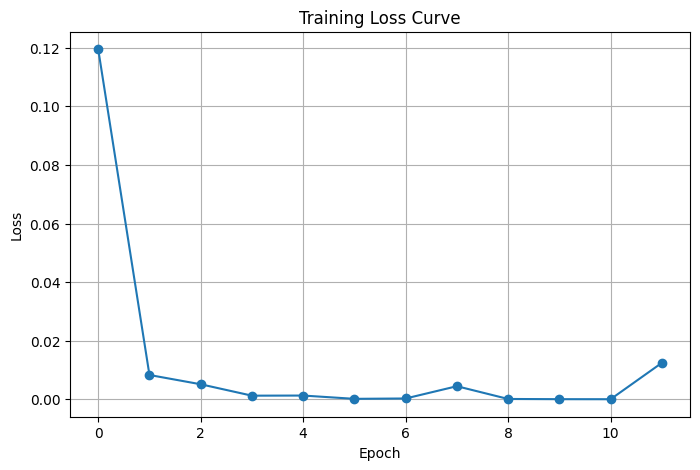

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, marker="o")
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

## Confusion Matrix
A confusion matrix provides a detailed view of the model’s predictions by comparing predicted labels with ground truth labels. This visualization reveals how many samples were correctly classified as normal or anomalous, as well as the number of false positives and false negatives. In structural anomaly detection systems, false negatives are particularly important because failing to detect a structural issue may lead to safety risks. The confusion matrix therefore helps diagnose model weaknesses and identify whether the classifier is biased toward a particular class.

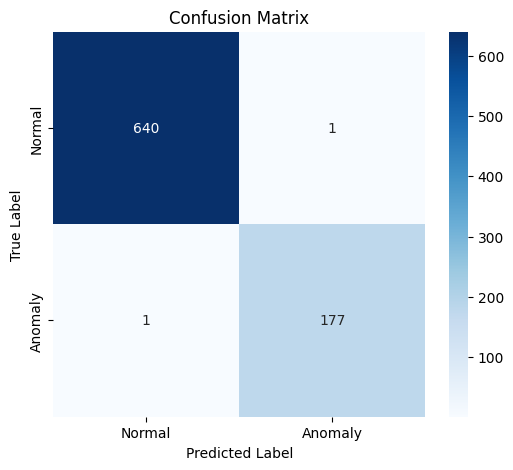

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(truth, preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Normal","Anomaly"],
            yticklabels=["Normal","Anomaly"])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Feature Space Visualization using PCA
Understanding how the multimodal feature representations cluster in feature space can provide insight into how well the model separates normal and anomalous structural conditions. Principal Component Analysis (PCA) is used to reduce the high dimensional fused feature vector into two dimensions for visualization. If the multimodal fusion network successfully captures meaningful relationships between visual and acoustic patterns, the resulting clusters should show clear separation between normal and anomaly classes.

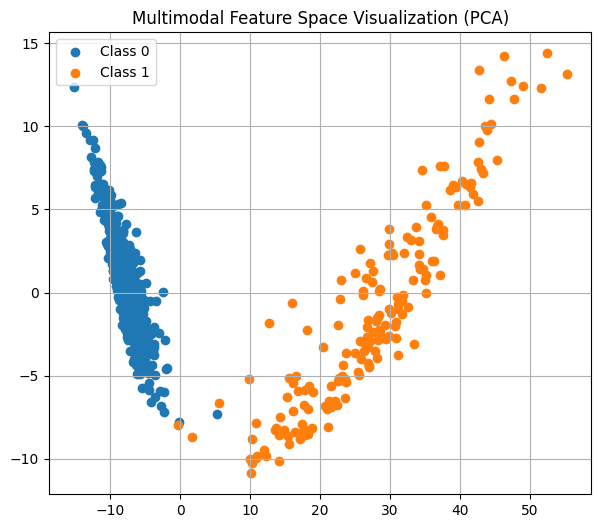

In [19]:
from sklearn.decomposition import PCA

fusion_model.eval()
features = []
labels_list = []

with torch.no_grad():
    for images, specs, labels in val_loader:
        images = images.to(device)
        specs = specs.to(device)
        img_feat = resnet(images)
        aud_feat = audio_model(specs)
        fused = torch.cat((img_feat, aud_feat), dim=1)
        features.extend(fused.cpu().numpy())
        labels_list.extend(labels.numpy())

features = np.array(features)
pca = PCA(n_components=2)
reduced = pca.fit_transform(features)
plt.figure(figsize=(7,6))

for label in np.unique(labels_list):
    idx = np.array(labels_list) == label
    plt.scatter(reduced[idx,0], reduced[idx,1], label=f"Class {label}")

plt.title("Multimodal Feature Space Visualization (PCA)")
plt.legend()
plt.grid()
plt.show()

## Example Predictions Visualization
Visualizing model predictions alongside the corresponding images provides an intuitive understanding of the model’s performance. This section displays a small set of validation images along with the predicted class labels produced by the multimodal fusion network. By examining these examples, we can qualitatively assess whether the model correctly identifies structural anomalies and how confidently it classifies different types of surface patterns.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.38830382..1.2108063].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.5699118..2.535425].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.27956167..1.8905448].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49105233..0.3452382].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.32296288..1.6666666].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.43967807..2.5179958].


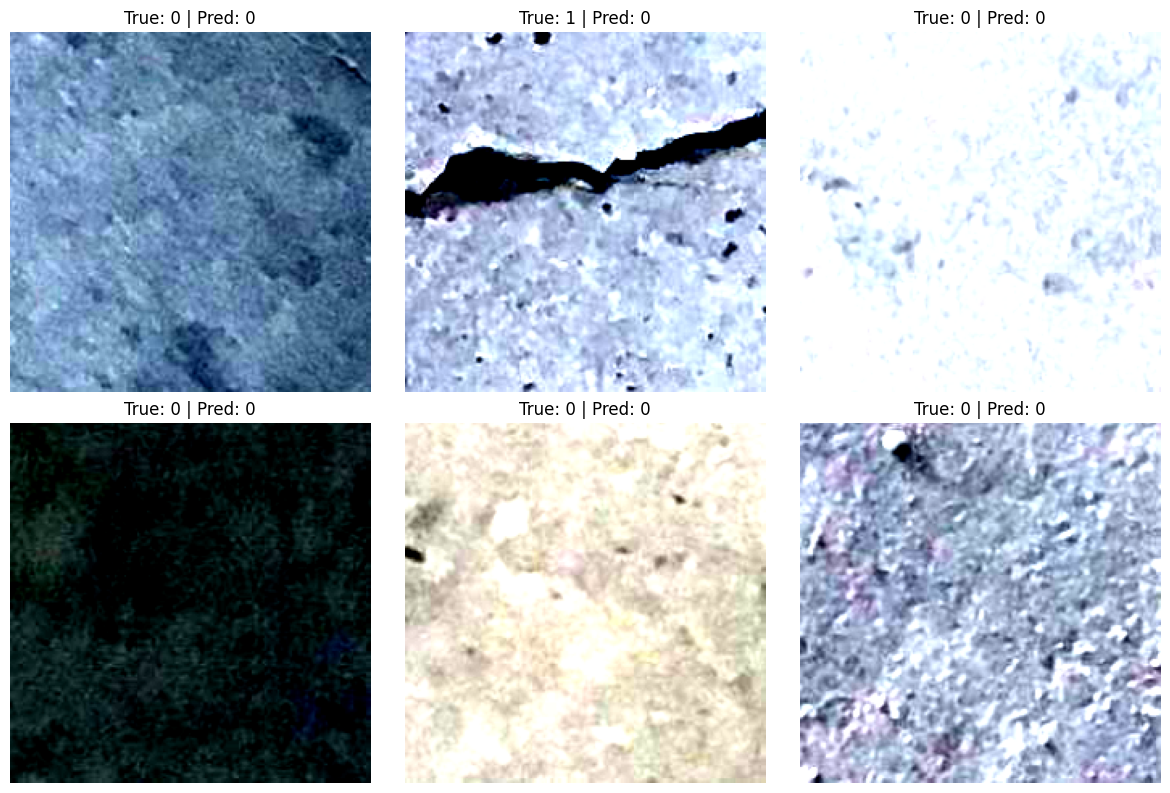

In [20]:
import random

fusion_model.eval()
indices = random.sample(range(len(val_dataset)), 6)
plt.figure(figsize=(12,8))

for i, idx in enumerate(indices):
    image, spec, label = val_dataset[idx]
    with torch.no_grad():
        img = image.unsqueeze(0).to(device)
        sp = spec.unsqueeze(0).to(device)
        img_feat = resnet(img)
        aud_feat = audio_model(sp)
        out = fusion_model(img_feat, aud_feat)
        pred = torch.argmax(out, dim=1).item()
    plt.subplot(2,3,i+1)
    plt.imshow(image.permute(1,2,0).numpy())
    plt.title(f"True: {label} | Pred: {pred}")
    plt.axis("off")
plt.tight_layout()
plt.show()